<a href="https://colab.research.google.com/github/KarinaSelingardi/ESTUDOS-DE-PYTHON/blob/main/adaptativa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importação das bibliotecas
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
from google.colab  import drive
drive.mount('/content/drive')
!ls

Mounted at /content/drive
drive  sample_data


In [ ]:
def mostrar(imagem):
    fig = plt.gcf()
    fig.set_size_inches(18,6)
    plt.axis('off')
    plt.imshow(imagem, cmap='gray')
    plt.show()

In [ ]:
def limiarizacao_adaptativa(img, limiar = 148, block_size = 11, C = 9):
    _, limiar_global = cv2.threshold(img, limiar, 255, cv2.THRESH_BINARY)
    limiar_media = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, block_size, C)
    limiar_gauss = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, block_size, C)

    imagens = [img, limiar_global, limiar_media, limiar_gauss]
    titulos = ['Imagem original','Limiarização global','Limiarização adaptativa = média','Limiarização adaptativa = gaussiana']

    fig = plt.gcf()
    fig.set_size_inches(18,12)

    for i in range(4):
        plt.subplot(2,2,i+1)
        plt.imshow(cv2.cvtColor(imagens[i], cv2.COLOR_BGR2RGB), cmap='gray')
        plt.title(titulos[i])
        plt.xticks([]),plt.yticks([])

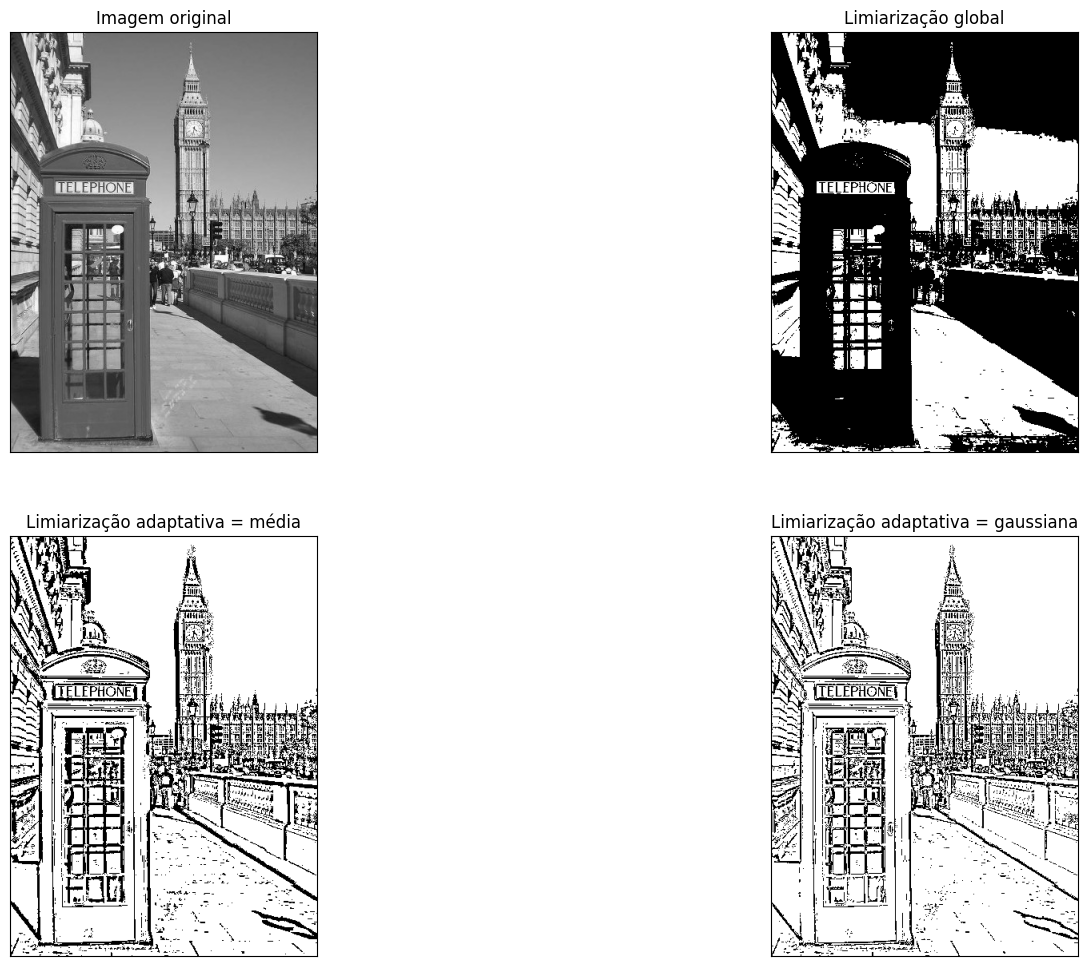

In [ ]:
img = cv2.imread('/content/drive/MyDrive/imagens/london-red-phonebox.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
limiarizacao_adaptativa(gray)

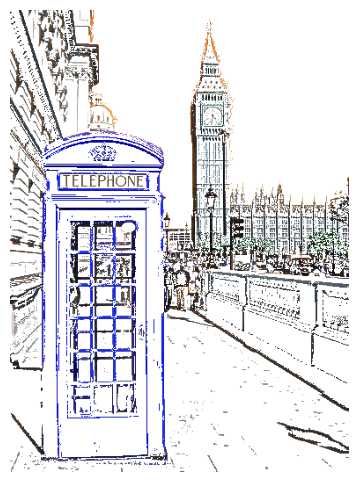

In [ ]:
adapt_gauss = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 15, 11)
sobrepor = cv2.add(img, cv2.cvtColor(adapt_gauss, cv2.COLOR_GRAY2BGR))
mostrar(sobrepor)

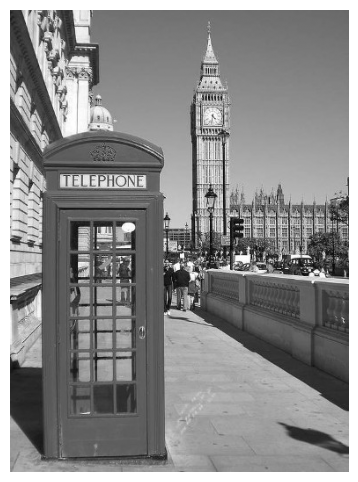

In [ ]:
img = cv2.imread('/content/drive/MyDrive/imagens/london-red-phonebox.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
mostrar(gray)

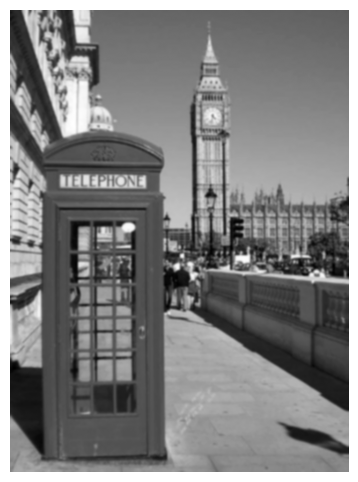

In [ ]:
desfoque = cv2.GaussianBlur(gray, (5,5), 0)
mostrar(desfoque)

In [ ]:
#Primeiro maneira
k_sobelX = np.array(([-1, 0, 1],
                     [-2, 0, 2],
                     [-1, 0, 1]), np.float32)
k_sobelY = np.array(([-1, -2, -1],
                     [0, 0, 0],
                     [1, 2, 1]), np.float32)

sobel_x = cv2.filter2D(desfoque, cv2.CV_64F, k_sobelX)
sobel_y = cv2.filter2D(desfoque, cv2.CV_64F, k_sobelY)

In [ ]:
sobel_x = cv2.convertScaleAbs(sobel_x)
sobel_y = cv2.convertScaleAbs(sobel_y)

In [ ]:
sobel_x = cv2.Sobel(desfoque, cv2.CV_64F, 1, 0, ksize = 3)
sobel_y = cv2.Sobel(desfoque, cv2.CV_64F, 0, 1, ksize = 3)

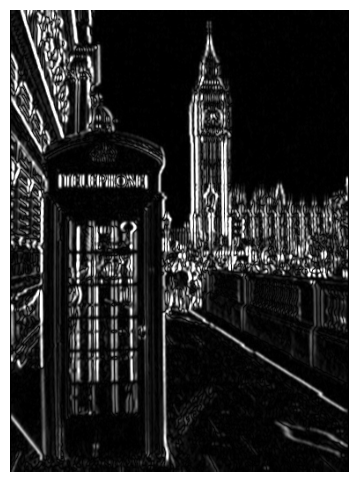

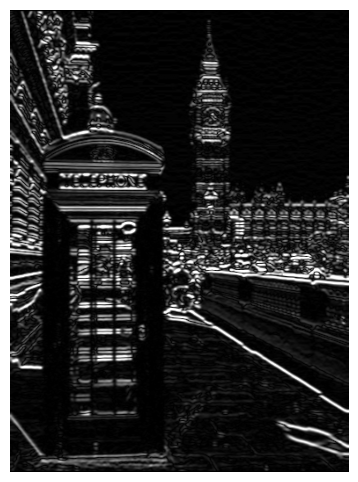

In [ ]:
mostrar(sobel_x)
mostrar(sobel_y)

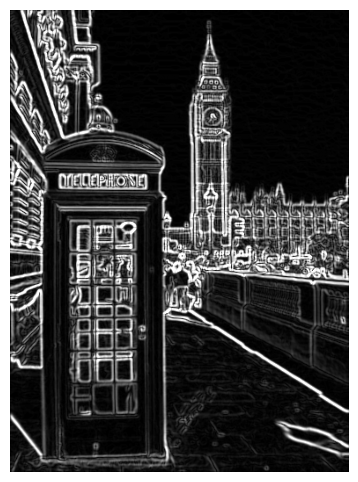

In [ ]:
sobel = cv2.addWeighted(src1 = sobel_x, alpha=0.5, src2 = sobel_y, beta = 0.5, gamma = 100)
mostrar(sobel)